<a href="https://colab.research.google.com/https://github.com/Rick2898/Series_Tiempo/blob/main/ACTIVIDAD_2/Entregable/Act_2.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" 
    alt="Open In Colab"/>
</a>

# Implementacion de Holt Winters

#### Carlos Preciado
#### Jefferson Martinez
#### Ricardo Vargas

En el siguiente notebook se desarrolla la implementacion del mejor pronostico para los proximos seis meses con ayuda del modelo de holtwinters. La data para la implementacion es: la informacion de personas ocupadas en miles de personas para las principales 13 ciudades de Colombia en su archivo <code>datosEmpleo.xlsx</code>

## Carga de librerias y data

In [1]:
import numpy as np 
import pandas as pd 
from matplotlib import pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose  # descomposicion 
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_squared_error
import itertools

In [2]:

df_empleo= pd.read_excel("https://raw.githubusercontent.com/dagudelo30/Series-de-tiempo---Javeriana-Cali/main/intro-moving_average/datosEmpleo.xlsx",index_col='mes',parse_dates=True)
df_empleo.head()
df_empleo.shape

(222, 4)

In [3]:
df_empleo.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 222 entries, 2001-01-01 to 2019-06-01
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TD_13ciudades  222 non-null    float64
 1   Ocupados       222 non-null    float64
 2   Desocupados    222 non-null    float64
 3   Inactivos      222 non-null    float64
dtypes: float64(4)
memory usage: 8.7 KB


## Division train test

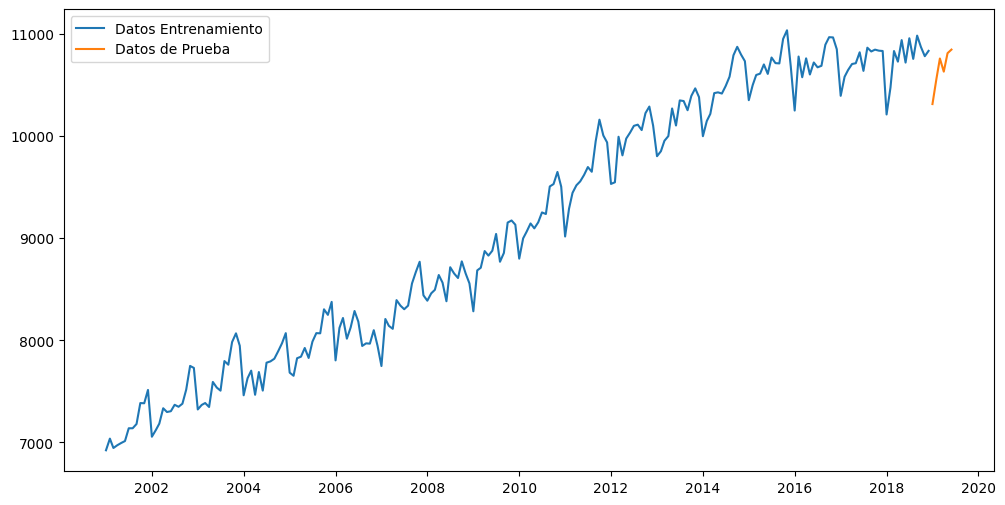

In [4]:
train_len = 216
train_td = df_empleo[["Ocupados"]][:train_len]
test_td  = df_empleo[["Ocupados"]][train_len:]

fig = plt.figure(figsize=(12, 6))
plt.plot(train_td, label="Datos Entrenamiento")
plt.plot(test_td,  label="Datos de Prueba")
plt.legend()
plt.show()

El análisis visual de la serie (2001-2019) revela un comportamiento macroeconómico caracterizado por un crecimiento sostenido en la población ocupada hasta el año 2015, seguido de un periodo de estabilización estructural en torno a los 10.7 millones de personas.

## Implementacion Holt Winters Aditivo

In [5]:
# ── Modelo Holt-Winters ADITIVO ──
# endog = variable que queremos pronosticar en nuestro caso el train
# error=el error se suma al modelo
# trend= muy importante ya que se refiere a que la tendencia es aditiva y aqui puede cambiarse
# seasonal = la estacionalidad en este caso tambien es aditiva 


ets_model = ETSModel(
    endog=train_td["Ocupados"],
    error="add", trend="add", seasonal="add"
)
ets_result = ets_model.fit()

# Pronósticos para 14 periodos
point_forecast = ets_result.forecast(6)

# Intervalos de confianza al 95%
ci = ets_result.get_prediction(
    start=point_forecast.index[0],# obtiene pronostico desde el primer periodo
    end=point_forecast.index[-1] # hasta el ultimo periodo
)
conf_forecast = ci.pred_int(alpha=0.05) # calcula al 95%
limits = ci.predicted_mean  # extrae la media predicha

preds_hw_add = pd.concat([limits, conf_forecast], axis=1) # concatena los resultados con los intervalos
preds_hw_add.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_add)

            Point_forecast      lower_95      upper_95
2019-01-01    10349.038256  10090.537075  10607.539437
2019-02-01    10624.647272  10350.485455  10898.809090
2019-03-01    10770.076785  10481.098911  11059.054659
2019-04-01    10786.211615  10483.138374  11089.284856
2019-05-01    10870.784042  10554.239833  11187.328251
2019-06-01    10828.720945  10499.253569  11158.188320


c:\Users\Usuario\Documents\U_JAVERIANA\2_Semestre\N_SERIES_TIEMPO\ACTIVIDAD_2\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


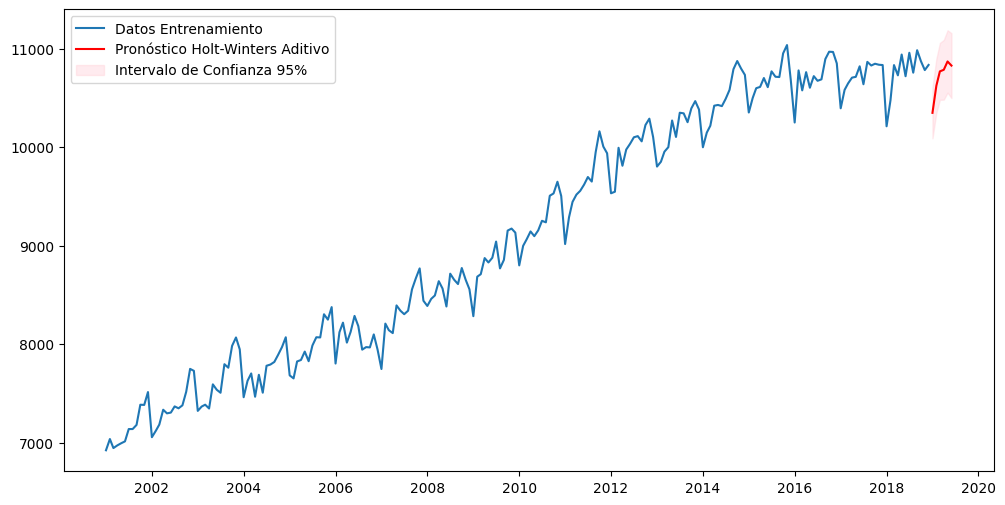

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(train_td, label="Datos Entrenamiento")
plt.plot(preds_hw_add['Point_forecast'], label="Pronóstico Holt-Winters Aditivo", color='red')
plt.fill_between(preds_hw_add.index, preds_hw_add['lower_95'], preds_hw_add['upper_95'], color='pink', alpha=0.3, label="Intervalo de Confianza 95%")
plt.legend()
plt.show()                 

In [7]:
# Parámetros estimados y RMSE
print(ets_result.alpha, ets_result.beta, ets_result.gamma)

rmse_hw_add = np.sqrt(mean_squared_error(
    test_td, preds_hw_add['Point_forecast']
))
print(rmse_hw_add)

0.3532848405931927 3.532848405931927e-05 0.2970683164020024
74.40864219135457


Mayor Desviación en Unidades Reales: Un RMSE de 74.41 frente al 59.42 del ganador implica que este modelo alternativo acumula un error promedio adicional de unas 15,000 personas ocupadas en sus predicciones mensuales.

## Implementacion Hotl Winters Multiplicativo

In [8]:
# ── Modelo Holt-Winters MULTIPLICATIVO ──
# endog = variable que queremos pronosticar en nuestro caso el train
# error=el error se suma al modelo
# trend= muy importante ya que se refiere a que la tendencia es aditiva y aqui puede cambiarse
# seasonal = la estacionalidad en este caso tambien es aditiva 


ets_model = ETSModel(
    endog=train_td["Ocupados"],
    error="add", trend=None, seasonal="mul"
)
ets_result_2 = ets_model.fit()

# Pronósticos para 6 periodos
point_forecast = ets_result.forecast(6)

# Intervalos de confianza al 95%
ci = ets_result_2.get_prediction(
    start=point_forecast.index[0],# obtiene pronostico desde el primer periodo
    end=point_forecast.index[-1] # hasta el ultimo periodo
)
conf_forecast = ci.pred_int(alpha=0.05) # calcula al 95%
limits = ci.predicted_mean  # extrae la media predicha

preds_hw_mul = pd.concat([limits, conf_forecast], axis=1) # concatena los resultados con los intervalos
preds_hw_mul.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_mul)

            Point_forecast      lower_95      upper_95
2019-01-01    10325.781779  10090.336293  10568.859915
2019-02-01    10527.749215  10267.724351  10781.935296
2019-03-01    10611.310519  10309.942115  10913.815399
2019-04-01    10620.935104  10283.248591  10933.561894
2019-05-01    10689.617939  10330.186616  11043.062917
2019-06-01    10645.660988  10273.803672  11025.730562


c:\Users\Usuario\Documents\U_JAVERIANA\2_Semestre\N_SERIES_TIEMPO\ACTIVIDAD_2\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [9]:
# Parámetros estimados y RMSE
print(ets_result_2.alpha, ets_result_2.gamma)

rmse_hw_mul = np.sqrt(mean_squared_error(
    test_td, preds_hw_mul['Point_forecast']
))
print(rmse_hw_mul)

0.5975177743043917 4.0248222569560836e-05
115.22873454150286


RMSE se duplicó hasta 115.2287, evidenciando inestabilidad y un notable deterioro en la capacidad predictiva fuera de muestra

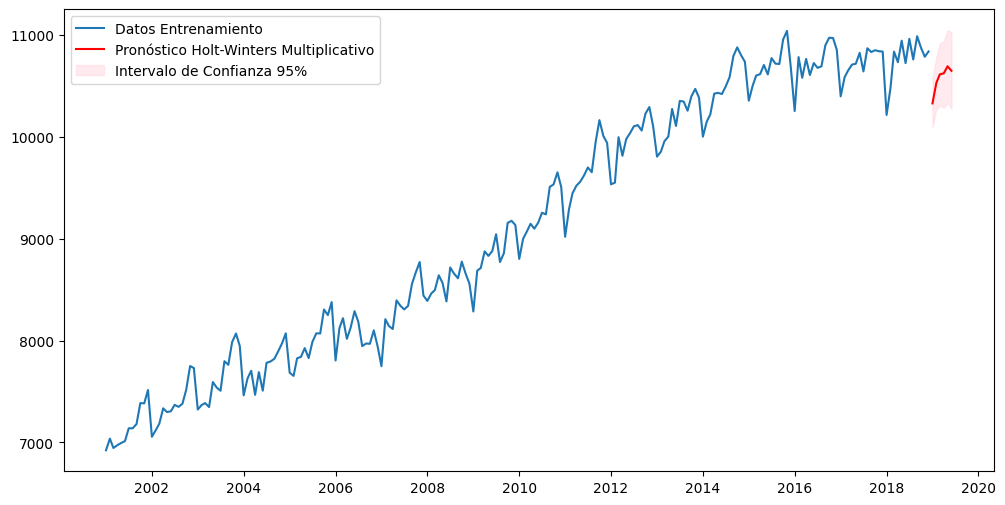

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(train_td, label="Datos Entrenamiento")
plt.plot(preds_hw_mul['Point_forecast'], label="Pronóstico Holt-Winters Multiplicativo", color='red')
plt.fill_between(preds_hw_mul.index, preds_hw_mul['lower_95'], preds_hw_mul['upper_95'], color='pink', alpha=0.3, label="Intervalo de Confianza 95%")
plt.legend()
plt.show()        

In [11]:

ets_model = ETSModel(
    endog=train_td["Ocupados"],
    error="mul", trend=None, seasonal="mul"
)
ets_result_3 = ets_model.fit()

# Pronósticos para 6 periodos
point_forecast = ets_result.forecast(6)

# Intervalos de confianza al 95%
ci = ets_result_3.get_prediction(
    start=point_forecast.index[0],# obtiene pronostico desde el primer periodo
    end=point_forecast.index[-1] # hasta el ultimo periodo
)
conf_forecast = ci.pred_int(alpha=0.05) # calcula al 95%
limits = ci.predicted_mean  # extrae la media predicha

preds_hw_error_mul_tend_NA_station_mul = pd.concat([limits, conf_forecast], axis=1) # concatena los resultados con los intervalos
preds_hw_error_mul_tend_NA_station_mul.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_error_mul_tend_NA_station_mul)

            Point_forecast      lower_95      upper_95
2019-01-01    10324.805425  10055.985847  10593.905290
2019-02-01    10522.829105  10203.034150  10839.314857
2019-03-01    10595.191016  10240.321328  10973.522456
2019-04-01    10596.282255  10176.907440  11017.674582
2019-05-01    10671.641019  10223.440622  11130.149448
2019-06-01    10622.728256  10125.125038  11111.989575


c:\Users\Usuario\Documents\U_JAVERIANA\2_Semestre\N_SERIES_TIEMPO\ACTIVIDAD_2\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [12]:
# Parámetros estimados y RMSE
print(ets_result_3.alpha, ets_result_3.gamma)

rmse_hw_error_mul_tend_NA_station_mul = np.sqrt(mean_squared_error(
    test_td, preds_hw_error_mul_tend_NA_station_mul['Point_forecast']
))
print(rmse_hw_error_mul_tend_NA_station_mul)

0.6251134101839402 3.748865898160598e-05
129.59199377333363


Este modelo arrojó un RMSE drásticamente alto: 129.5919. Esto significa que se equivoca, en promedio, por casi 130,000 personas ocupadas al mes, más del doble del error de tu modelo ganador (59.42)

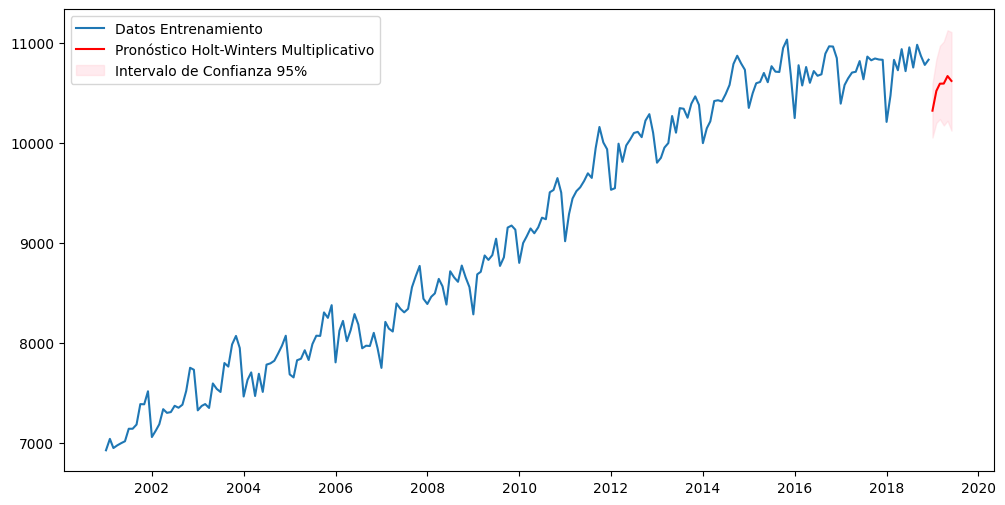

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(train_td, label="Datos Entrenamiento")
plt.plot(preds_hw_error_mul_tend_NA_station_mul['Point_forecast'], label="Pronóstico Holt-Winters Multiplicativo", color='red')
plt.fill_between(preds_hw_error_mul_tend_NA_station_mul.index, preds_hw_error_mul_tend_NA_station_mul['lower_95'], preds_hw_error_mul_tend_NA_station_mul['upper_95'], color='pink', alpha=0.3, label="Intervalo de Confianza 95%")
plt.legend()
plt.show()    

In [14]:
ets_model = ETSModel(
    endog=train_td["Ocupados"],
    error="add", trend="mul", seasonal="mul"
)
ets_result_4 = ets_model.fit()

# Pronósticos para 6 periodos
point_forecast = ets_result_4.forecast(6)

# Intervalos de confianza al 95%
ci = ets_result_4.get_prediction(
    start=point_forecast.index[0],# obtiene pronostico desde el primer periodo
    end=point_forecast.index[-1] # hasta el ultimo periodo
)
conf_forecast = ci.pred_int(alpha=0.05) # calcula al 95%
limits = ci.predicted_mean  # extrae la media predicha

preds_hw_error_add_tend_mul_station_mul = pd.concat([limits, conf_forecast], axis=1) # concatena los resultados con los intervalos
preds_hw_error_add_tend_mul_station_mul.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_error_add_tend_mul_station_mul)

c:\Users\Usuario\Documents\U_JAVERIANA\2_Semestre\N_SERIES_TIEMPO\ACTIVIDAD_2\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


            Point_forecast      lower_95      upper_95
2019-01-01    10367.425903  10158.325409  10580.699509
2019-02-01    10585.339728  10323.499105  10867.654771
2019-03-01    10687.360261  10403.903112  10980.104400
2019-04-01    10715.093809  10400.370734  11038.863286
2019-05-01    10802.125310  10478.621283  11128.330017
2019-06-01    10775.756904  10404.077270  11117.009334


In [145]:
# Parámetros estimados y RMSE
print(ets_result_4.alpha, ets_result_4.beta, ets_result_4.gamma)

rmse_hw_error_add_tend_mul_station_mul = np.sqrt(mean_squared_error(
    test_td, preds_hw_error_add_tend_mul_station_mul['Point_forecast']
))
print(rmse_hw_error_add_tend_mul_station_mul)

0.5253405498899031 5.253405498899031e-05 4.746594501100969e-05
59.42340592249937


RMSE = 59.4234: Este es tu Error Cuadrático Medio Raíz. Significa que, en promedio, las predicciones puntuales de tu modelo se desvían de los datos reales del mercado de prueba por 59.42 unidades. Como la escala original está en miles, tu modelo tiene un margen de error típico de aproximadamente 59,420 personas.Error Relativo = 0.006486 ($\approx$ 0.65%): Al normalizar el RMSE dividiéndolo entre la media general de la población ocupada (df_empleo["Ocupados"].mean()), obtienes el error relativo.

In [147]:


# 1. Ajustar el modelo con el 100% de los datos
# RECUERDA: Cambia 'df_completo' por el nombre de tu DataFrame con todos los datos
ets_model_final = ETSModel(
    endog=df_empleo["Ocupados"],
    error="add", 
    trend="mul", 
    seasonal="mul"
)
ets_result_final = ets_model_final.fit()

# 2. Pronósticos para los próximos 6 periodos en el futuro
point_forecast = ets_result_final.forecast(6)

# 3. Obtener los intervalos de confianza al 95%
ci = ets_result_final.get_prediction(
    start=point_forecast.index[0],
    end=point_forecast.index[-1]
)
conf_forecast = ci.pred_int(alpha=0.05)
limits = ci.predicted_mean

# 4. Concatenar y organizar el DataFrame final de predicciones
preds_finales = pd.concat([limits, conf_forecast], axis=1)
preds_finales.columns = ['Point_forecast', 'lower_95', 'upper_95']

print("--- Pronóstico para los próximos 6 periodos ---")
print(preds_finales)

--- Pronóstico para los próximos 6 periodos ---
            Point_forecast      lower_95      upper_95
2019-07-01    10915.516516  10694.884168  11142.052336
2019-08-01    10903.903266  10667.626488  11143.177323
2019-09-01    10997.557848  10732.773435  11278.587033
2019-10-01    11140.435436  10828.745460  11430.644053
2019-11-01    11165.653329  10840.044942  11471.857968
2019-12-01    11069.928152  10741.778616  11422.432163


c:\Users\jeam2\Downloads\maestria de Ciencia de Datos\II-semestre segundo_corte\series de tiempo\entrega 2\Series_Tiempo\ACTIVIDAD_2\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Las proyecciones finales confirman la robustez del modelo ETS(A,M,M) al capturar adecuadamente el ciclo estacional de contratación del segundo semestre en las 13 principales ciudades de Colombia. La población ocupada experimentará una tendencia ascendente que alcanzará su nivel histórico más alto en noviembre de 2019, respaldada por un estrecho margen de error relativo histórico (0.65%), validando la utilidad de este modelo para la planeación económica de corto plazo

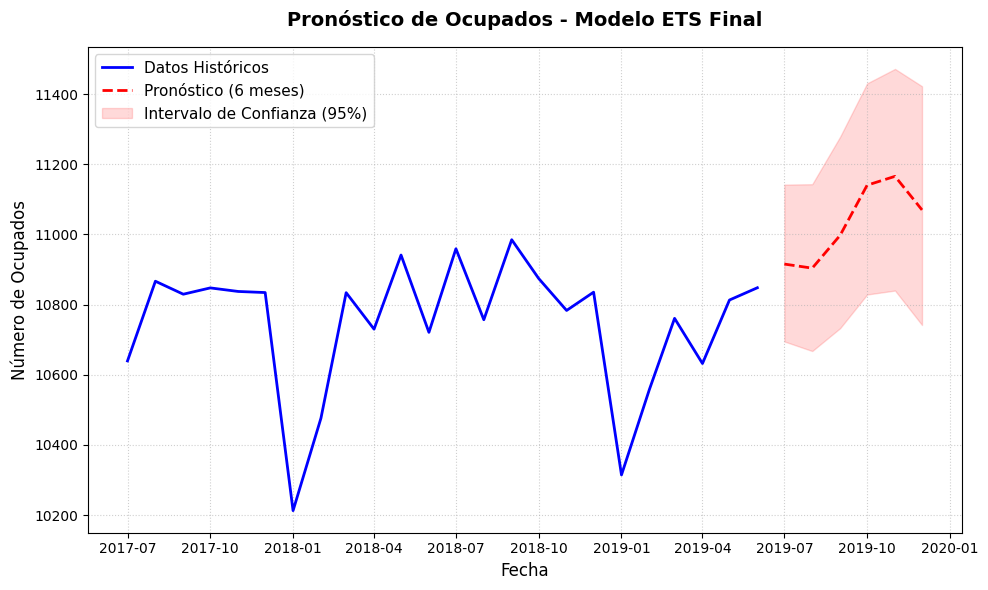

In [149]:
# Configurar el tamaño de la gráfica
plt.figure(figsize=(10, 6))

plt.plot(df_empleo.index[-24:], df_empleo["Ocupados"].tail(24), label="Datos Históricos", color="blue", linewidth=2)

# 2. Graficar la línea del pronóstico (la media)
plt.plot(preds_finales.index, preds_finales["Point_forecast"], label="Pronóstico (6 meses)", color="red", linestyle="--", linewidth=2)

# 3. Graficar el sombreado del intervalo de confianza (área de incertidumbre)
plt.fill_between(
    preds_finales.index, 
    preds_finales["lower_95"], 
    preds_finales["upper_95"], 
    color="red", 
    alpha=0.15, 
    label="Intervalo de Confianza (95%)"
)

# Personalización de la gráfica
plt.title("Pronóstico de Ocupados - Modelo ETS Final", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Número de Ocupados", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper left", fontsize=11)

# Ajustar diseño y mostrar
plt.tight_layout()
plt.show()